1) Prepare your work environment

In [ ]:
from pathlib import Path
from data_analysis import CSVDataAnalyzer
import dirty_data_generator as ddg
import pandas as pd

WORKDIR = Path.cwd()
DATAPATH = WORKDIR/"data/"
filename = DATAPATH/"dirty_dataset.csv"
pd.set_option({"display.max_columns": 200, "display.max_rows": 200})

2) To get started, we'll generate a dirty dataset with empty, duplicated and wrongly formatted values. The dataset has five fields, "name", "age", "province", "cie" and "money", which are all **fake data generated with Faker** (no real, personal data has been used for this project). 

Note that a wrong format "age", as defined in WrongFormatValues.py module, is just a negative age or an age greater than 122 (history's oldest person), so technically this is not a case of wrong format but rather *wrong* data. The same holds for money values, since a negative amount of money and a value preceded by the dollar ($) symbol are both recognized as the wrong format kind. These have been grouped with the *wrong format* data since this project is tiny and doing this avoid declaring a (not very useful) small class and rewriting the WrongFormatValues module.

In [ ]:
ddg.generate_dirty_csv(1200, filename, "it_IT", include_duplicates=True, max_number_of_duplicates=30)

3) The next step is to create a myAnalyzer object. It will be used to print statistics and clean data.

In [ ]:
myAnalyzer = CSVDataAnalyzer()

4) The read_data() method will read the dataset file and store it as a pd.DataFrame class attribute named myAnalizer._df.

In [ ]:
myAnalyzer.read_data(filename)

5) We can now print the database, which will likely be full of invalid or missing values...

In [ ]:
print(myAnalyzer._df.sample(20))

                               name   age province        cie    money
425               Maurilio Scalfaro  54.0       RA  TV98550IX  1083.45
822      Sig.ra Serafina Niscoromni  37.0       CI  JF70324HD  -638.21
325                 Antonia Versace  92.0       RA  BK18779ZG  1990.52
1095           Marta Oscuro-Vivaldi  50.0       NO  LA88212BJ   818.07
90                      Lilla Beffa   9.0       FE  vz64297kp  1879.53
132          Graziella Brunelleschi  22.0       PU  YF71535JO      NaN
599         Jolanda Gaito-Staglieno  25.0       UD  RC34551OZ      NaN
83                Maura Lamborghini  90.0       TV  RQ98309HJ   566.77
234        Sig.ra Victoria Venditti  49.0       PI  UY79028CR  2490.88
900                Temistocle Delle  78.0       PZ  ZP32059rm  1953.91
1145  Rodolfo Scaramucci-Filippelli  17.0       BA  XG89620QO   832.75
1158               Giorgia Nosiglia  21.0       SV  UJ15139UK   380.49
979        Sig. Donatello Carpaccio  39.0       PO  AJ50182RM  1798.58
126   

6) Calling the print_dirty_data_statistics() method will print information about missing and wrongly formatted data. For example, valid "name" field values should have a name and a surname, each starting with an uppercase letter, followed by lowercase letters; compound surnames, like Giordani-Rodari, are allowed. For more information about the regexs ruling data validation, see the WrongFormatValues.py module.

In [ ]:
myAnalyzer.print_dirty_data_statistics()

The number of missing and wrong occurences include duplicates.
Rows:	1230
Duplicates:	25
Wrong format:	329
|
|
---- wrong name:	248
|
|
---- wrong age:	21
|
|
---- wrong province:	19
|
|
---- wrong CIE:	23
|
|
---- wrong money:	42

Missing:	184
|
|
---- missing name:	18
|
|
---- missing age:	34
|
|
---- missing province:	65
|
|
---- missing CIE:	12
|
|
---- missing money:	67


7) Its graphic counterpart is the show_dirty_data_statistics()

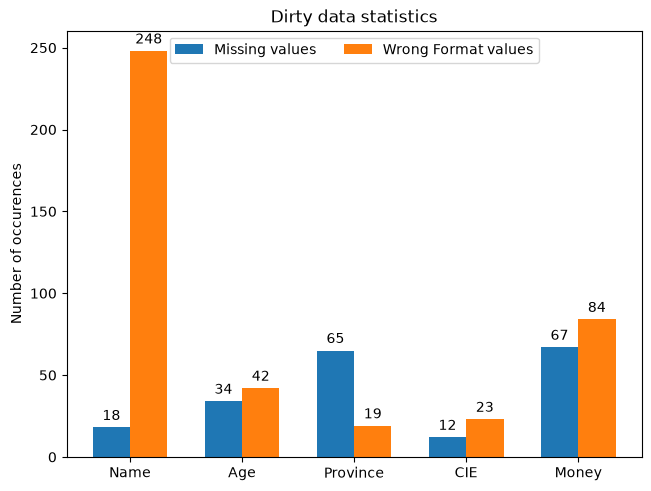

In [ ]:
myAnalyzer.show_dirty_data_statistics()

8) One could be interested in which are the X wealthiest and the Y poorest regions, grouping columns by "province" value and calculating the mean value of "money" for each province. This can be made with pandas, but wrongly format and missing data must be dealt with first. A first approach could be to exclude these faulty rows, removing them from the data population on which pandas will perform the mean operation. Here's a possible implementation:

In [ ]:
def show_wealth_by_province(self, num_of_poorest : int = 5, num_of_wealthiest : int = 5):
        df2 = self._df.copy()
        
        df2 = WF.drop_wrongFormat_rows(df2, ["money", "province"]) # Remove dirty data
        df2["money"] = pd.to_numeric(df2["money"]) #Since some rows have the "$" character, "money" column is treated as a str type

        group = df2.groupby(by ="province", dropna = True)["money"]
        group_mean = group.mean().sort_values(ascending = False)

        wealthiest_provinces = group_mean.iloc[0:num_of_wealthiest]
        poorest_provinces = group_mean.iloc[len(group_mean)-num_of_poorest : len(group_mean)]

        fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, layout="constrained")
        bar_colors = ["tab:red", "tab:orange", "tab:green", "tab:olive", "tab:blue"]

        ax1.bar(x = range(num_of_wealthiest), height = wealthiest_provinces, tick_label = wealthiest_provinces.keys(), color = bar_colors)
        ax2.bar(x = range(num_of_poorest), height = poorest_provinces, tick_label = poorest_provinces.keys(), color = bar_colors)
        
        ax1.set_ylabel("Average salary (€)")
        ax1.set_title(f"The {num_of_wealthiest} wealthiest regions")
        ax2.set_title(f"The {num_of_poorest} poorest regions")

        plt.show()

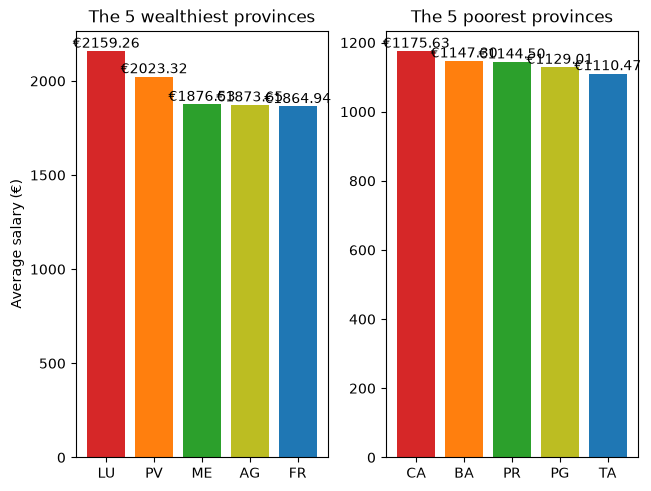

In [ ]:
myAnalyzer.show_wealth_by_province(num_of_poorest = 5, num_of_wealthiest = 5)

9) A similar approach can be used to classify wealth by age range, grouping different "age" values under the same label. The show_wealth_by_age() method does exactly this:

In [ ]:
 def show_wealth_by_age(self):
       """
       The solution to group age values was inspired by the following StackOverflow thread :] :
       https://stackoverflow.com/a/52753673
       """

       age_range = (0, 10, 18, 40, 65, 122)
       age_labels = ("Kids", "Teens", "Young adults", "Adults", "Elders")

       df2 = self._df.copy()
       df2.dropna(inplace=True)
       df2 = WF.drop_wrongFormat_rows(df2, ["age", "money"]) #That's a bit overkill because one could read negative ages and just flip 'em. 
                                                 #Anyway this is an example of how to deal with wrong data.
       
       df2["AgeGroup"] = pd.cut(df2["age"], bins = age_range, labels = age_labels, right = False)
       df2["money"] = pd.to_numeric(df2["money"]) #Since some rows have the "$" character, "money" column is treated as a str type

       group = df2.groupby(by = "AgeGroup", dropna = True)["money"]
       group_mean = group.mean().sort_values(ascending = False)
       bar_colors = ["tab:red", "tab:orange", "tab:green", "tab:olive", "tab:blue"]

       fig, ax = plt.subplots(layout = "constrained")
       ax.bar(x = range(5), height = [group_mean[x] for x in age_labels], tick_label = age_labels, color = bar_colors)
       ax.set_title("Average salary (€)")

       plt.show()


10) Notice: this function creates a clone dataframe with an additional field "AgeGroup" to store age classification values.

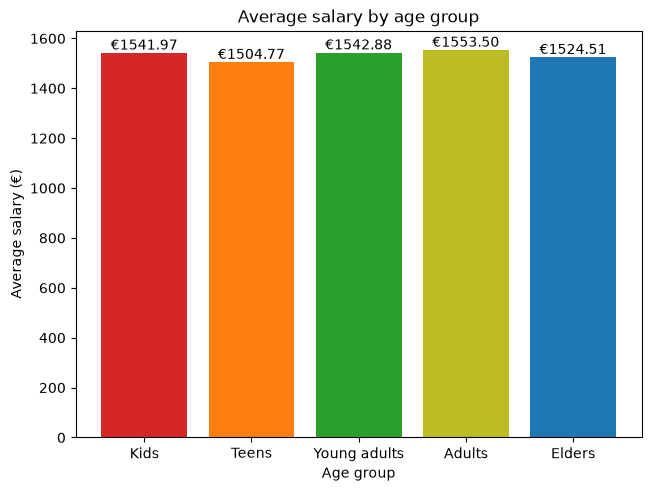

In [ ]:
myAnalyzer.show_wealth_by_age()

11) A possible improvement of this function could be to drop rows with "ageGroup" = "Kids", since they don't have a salary and the result doesn't have sense. Another approach could be to set the "money" field to zero for each row with "AgeGroup".

The second choice seems better, since setting money to zero for each "kid" row solves the problem for the show_wealth_by_province() method too, since "kid salaries" will be counted when evaluating the average salary for each province.